# 13_核方法-谱核

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这一小节，咱们来聊聊谱核\~

首先，**核方法**是一种用来处理非线性问题的技巧。

打个比方：

> 你有一堆二维点（比如在平面上），它们看起来怎么都分不开，但是如果你把它们“抛”到一个更高维的空间（比如三维），你会发现它们可以被一条平面轻松分开。

这个“抛”到高维空间的过程就叫**映射**。而**核方法**的关键点是：**我们不用真的去做这个映射，而是通过一个叫“核函数”的工具，直接计算映射后的结果**。

### 谱核是什么？

**谱核（Spectral Kernel）**是核方法中的一种特殊的核函数，它和“频率”有关。

**怎么理解“频率”？**

你可以把数据看成是波，或者看成图像、信号，那里面就有“高频”和“低频”的成分。谱核就像一个**用频率来分析数据相似性**的工具。

谱核的本质，用频率（或者叫“特征频谱”）的方式来衡量两个数据之间的相似性。

“谱” 指的是“频谱”，也就是把函数或信号拆解成不同频率成分的过程，像傅里叶变换就是一种谱分析。

那么，为什么要用谱核？因为在某些问题里，数据的“频率特征”比原始值更能反映相似性。例如音频处理、图像纹理分类、图结构分析等。

### 举个简单例子：

假设你有两个信号片段（比如两段声音）：

- 它们的原始数值不同，但频谱相似（都有很多低频、少量高频）
- 用普通的核方法（比如线性核）看起来它们相差很大
- 用谱核来比对频率成分，你会发现它们其实很像

所以谱核就更适合这种“频率结构相似”的任务。

总之，谱核是一种用频率成分（或者图的频谱）来衡量数据相似性的核函数，非常适合分析那些结构或信号中频率特征很重要的任务。

## 原理详解

### 1. 核方法回顾：从特征映射到核函数

核方法的目标是在一个**隐式的高维空间**中实现对输入数据的线性操作。

#### 特征映射与核函数

设有输入空间 $\mathcal{X}$，对任意数据 $x \in \mathcal{X}$，我们引入一个特征映射函数：


$$
\phi: \mathcal{X} \rightarrow \mathcal{H}
$$


其中 $\mathcal{H}$ 是某个高维（或无限维）希尔伯特空间。

我们关心的是内积 $\langle \phi(x), \phi(x') \rangle$，不直接关心 $\phi(x)$ 本身。

于是引入**核函数** $k$：


$$
k(x, x') = \langle \phi(x), \phi(x') \rangle
$$


### 2.核函数的构造思路：从 Mercer 定理出发

#### Mercer 定理

假设核函数 $k(x, x')$ 是连续、对称的，且在 $\mathcal{X} \subset \mathbb{R}^d$ 上是正定的，那么根据 Mercer 定理：


$$
k(x, x') = \sum_{i=1}^{\infty} \lambda_i \psi_i(x) \psi_i(x')
$$


其中：

- $\lambda_i \ge 0$：特征值
- $\psi_i(x)$：一组正交的特征函数，满足：


$$
\int_\mathcal{X} k(x, x') \psi_i(x') dx' = \lambda_i \psi_i(x)
$$


这个展开类似于傅里叶分解，把核函数表示为频谱（谱）的形式：**这就是谱核的数学基础**。

### 3. 谱核的基本定义与构造

谱核就是**基于输入的频谱表示或特征谱构造出来的核函数**。

#### 频域视角下的核函数：Bochner 定理

对于输入空间 $\mathbb{R}^d$ 上的**平移不变核函数** $k(x, x') = k(x - x')$，Bochner 定理说明：

> 一个函数 $k(\delta)$ 是平移不变的正定核 ⇔ 它是某个概率分布的傅里叶变换。

即：


$$
k(x - x') = \int_{\mathbb{R}^d} e^{i \omega^\top(x - x')} p(\omega) d\omega
$$


其中：

- $p(\omega)$：频率空间上的概率密度（频谱）
- $\omega$：频率变量

这个积分就是**谱核的核心公式**，说明核函数可以通过频率空间的加权平均构造出来。

### 4. 谱核的推导过程（基于 Bochner 定理）

我们将 Bochner 积分表示进行变换：


$$
k(x, x') = \int_{\mathbb{R}^d} e^{i \omega^\top(x - x')} p(\omega) d\omega= \int_{\mathbb{R}^d} \cos(\omega^\top (x - x')) p(\omega) d\omega
$$


其中使用了 $e^{i\theta} = \cos(\theta) + i\sin(\theta)$，并利用核函数实值性，去掉虚部。

#### 特征映射的隐式构造

定义隐式特征映射：


$$
\phi_\omega(x) = \sqrt{2} \cos(\omega^\top x + b), \quad b \sim \text{Uniform}[0, 2\pi]
$$


取 $\omega \sim p(\omega)$，则有：


$$
k(x, x') = \mathbb{E}_{\omega, b}[\phi_\omega(x)\phi_\omega(x')]
$$


这是一种近似谱核的方式：**谱核通过采样频率** $\omega$ **构造内积来近似核函数**。

### 5. 谱核的构造算法流程（简化版）

基于上面的理论，可以得出谱核的典型构造流程：

**输入**：

- 数据点 $x_1, x_2, \dots, x_n \in \mathbb{R}^d$
- 所需核函数（如 RBF）
- 对应的频谱分布 $p(\omega)$

**步骤一：确定频谱分布**

根据目标核函数，确定它对应的频谱分布。例如：

RBF 核（高斯核）：


$$
k(x, x') = \exp\left(-\frac{\|x - x'\|^2}{2\sigma^2}\right)\Rightarrow p(\omega) = \mathcal{N}(0, \sigma^{-2}I)
$$


**步骤二：采样频率**

从频谱分布 $p(\omega)$ 中采样 $D$ 个频率向量：


$$
\omega_1, \omega_2, \dots, \omega_D \sim p(\omega)
$$


再从 $[0, 2\pi]$ 中采样 $b_1, \dots, b_D$

**步骤三：构造特征映射**

定义特征映射为：


$$
\phi(x) = \sqrt{\frac{2}{D}} \begin{bmatrix}\cos(\omega_1^\top x + b_1) \\\vdots \\\cos(\omega_D^\top x + b_D)\end{bmatrix}\in \mathbb{R}^D
$$


**步骤四：谱核近似**

谱核函数近似为：


$$
k(x, x') \approx \phi(x)^\top \phi(x')
$$


你就可以用这个内积值替代传统核函数使用了。此近似叫做**随机傅里叶特征法（Random Fourier Features）**。

### 6. 图谱核（扩展）

在图数据中，谱核还可以基于**图拉普拉斯矩阵的特征分解**构造：

#### 图拉普拉斯

对于图 $G=(V,E)$，定义图拉普拉斯：


$$
L = D - A
$$


或归一化版本：


$$
L_{sym} = I - D^{-1/2} A D^{-1/2}
$$


- $A$：邻接矩阵
- $D$：度矩阵

对 $L$ 做特征分解：

- $L = U \Lambda U^\top$
- $U$：特征向量（图频率基）
- $\Lambda$：特征值（频率）

谱核使用这些谱信息构造图之间的相似度。

## 完整案例

使用谱核对非线性二维数据进行分类，假设我们有一组二维点，它们在平面上分布得比较复杂，单纯线性方法无法有效分类。我们通过构造**基于随机傅里叶特征的谱核**，用核方法提升分类性能。

- 生成非线性可分二维数据（类似“同心圆”数据）
- 使用谱核（基于随机傅里叶特征的近似RBF核）构建特征映射
- 结合线性分类器完成分类任务
- 可视化原始数据和分类边界
- 优化随机傅里叶特征维度，观察效果变化

#### 完整代码

训练集准确率: 0.9524
测试集准确率: 0.9528


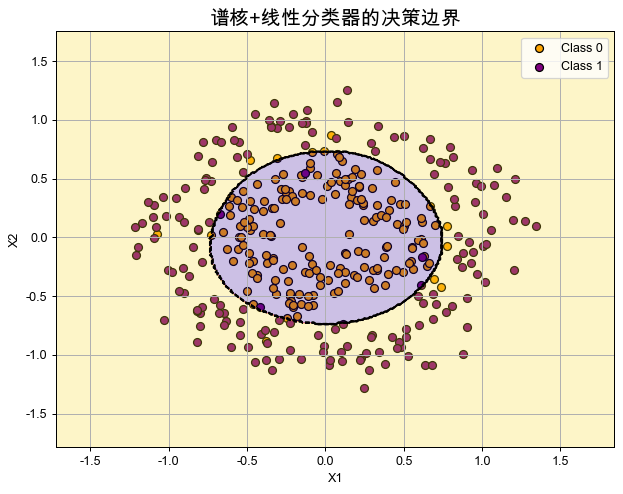

D=50, sigma=0.1, 测试准确率=0.8083
D=50, sigma=0.3, 测试准确率=0.9417
D=50, sigma=0.5, 测试准确率=0.9556
D=50, sigma=1.0, 测试准确率=0.9528
D=50, sigma=2.0, 测试准确率=0.9000
D=100, sigma=0.1, 测试准确率=0.8778
D=100, sigma=0.3, 测试准确率=0.9611
D=100, sigma=0.5, 测试准确率=0.9583
D=100, sigma=1.0, 测试准确率=0.9611
D=100, sigma=2.0, 测试准确率=0.9472
D=300, sigma=0.1, 测试准确率=0.9389
D=300, sigma=0.3, 测试准确率=0.9611
D=300, sigma=0.5, 测试准确率=0.9611
D=300, sigma=1.0, 测试准确率=0.9500
D=300, sigma=2.0, 测试准确率=0.9500
D=500, sigma=0.1, 测试准确率=0.9583
D=500, sigma=0.3, 测试准确率=0.9556
D=500, sigma=0.5, 测试准确率=0.9556
D=500, sigma=1.0, 测试准确率=0.9528
D=500, sigma=2.0, 测试准确率=0.9528
D=1000, sigma=0.1, 测试准确率=0.9583
D=1000, sigma=0.3, 测试准确率=0.9583
D=1000, sigma=0.5, 测试准确率=0.9583
D=1000, sigma=1.0, 测试准确率=0.9583
D=1000, sigma=2.0, 测试准确率=0.9444
最佳参数: {'D': 100, 'sigma': 0.3}, 对应测试准确率: 0.9611


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# 1. 生成数据：非线性同心圆数据
def generate_concentric_circles(n_samples=2000, noise=0.1):
    np.random.seed(42)
    n_samples_per_class = n_samples // 2

    # 类别0: 小圆，半径0.5
    r0 = 0.5 + noise * np.random.randn(n_samples_per_class)
    theta0 = 2 * np.pi * np.random.rand(n_samples_per_class)
    x0 = np.vstack([r0 * np.cos(theta0), r0 * np.sin(theta0)]).T

    # 类别1: 大圆，半径1.0
    r1 = 1.0 + noise * np.random.randn(n_samples_per_class)
    theta1 = 2 * np.pi * np.random.rand(n_samples_per_class)
    x1 = np.vstack([r1 * np.cos(theta1), r1 * np.sin(theta1)]).T

    X = np.vstack([x0, x1])
    y = np.array([0]*n_samples_per_class + [1]*n_samples_per_class)
    return X, y

# 2. 构造随机傅里叶特征 (谱核特征映射)
class RandomFourierFeatures:
    def __init__(self, D, sigma=1.0):
        self.D = D            # 特征维度
        self.sigma = sigma    # RBF核的带宽参数
        self.W = None
        self.b = None

    def fit(self, X):
        d = X.shape[1]
        # 采样频率向量，满足N(0, 1/sigma^2)
        self.W = np.random.normal(loc=0, scale=1/self.sigma, size=(self.D, d))
        self.b = np.random.uniform(0, 2*np.pi, size=self.D)

    def transform(self, X):
        # 计算随机傅里叶特征映射
        projection = X @ self.W.T + self.b
        Z = np.sqrt(2/self.D) * np.cos(projection)
        return Z

# 3. 数据生成
X, y = generate_concentric_circles(n_samples=1200, noise=0.15)

# 4. 划分训练测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 5. 谱核特征映射
D = 500             # 随机傅里叶特征维度，越大越准确
sigma = 0.5         # RBF核带宽
rff = RandomFourierFeatures(D=D, sigma=sigma)
rff.fit(X_train)
Z_train = rff.transform(X_train)
Z_test = rff.transform(X_test)

# 6. 训练线性分类器
clf = LogisticRegression(max_iter=1000)
clf.fit(Z_train, y_train)

# 7. 预测与评估
y_pred_train = clf.predict(Z_train)
y_pred_test = clf.predict(Z_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"训练集准确率: {acc_train:.4f}")
print(f"测试集准确率: {acc_test:.4f}")

# 8. 可视化数据和决策边界
def plot_decision_boundary(clf, rff, X, y, title):
    plt.figure(figsize=(8, 6))
    # 画点
    plt.scatter(X[y==0][:,0], X[y==0][:,1], c='orange', label='Class 0', edgecolor='k', s=40)
    plt.scatter(X[y==1][:,0], X[y==1][:,1], c='purple', label='Class 1', edgecolor='k', s=40)

    # 创建网格，预测网格点类别
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z_grid = clf.predict(rff.transform(grid))
    Z_grid = Z_grid.reshape(xx.shape)

    # 绘制决策边界及区域填充
    plt.contourf(xx, yy, Z_grid, alpha=0.25, cmap='plasma')
    plt.contour(xx, yy, Z_grid, colors='k', linewidths=1, linestyles='--')

    plt.title(title, fontsize=16)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_decision_boundary(clf, rff, X_test, y_test, "谱核+线性分类器的决策边界")

# 9. 算法优化：维度与带宽调优

dims = [50, 100, 300, 500, 1000]
sigma_vals = [0.1, 0.3, 0.5, 1.0, 2.0]

best_acc = 0
best_params = {}

for D_opt in dims:
    for sigma_opt in sigma_vals:
        rff_opt = RandomFourierFeatures(D=D_opt, sigma=sigma_opt)
        rff_opt.fit(X_train)
        Z_train_opt = rff_opt.transform(X_train)
        Z_test_opt = rff_opt.transform(X_test)
        clf_opt = LogisticRegression(max_iter=1000)
        clf_opt.fit(Z_train_opt, y_train)
        y_test_pred_opt = clf_opt.predict(Z_test_opt)
        acc = accuracy_score(y_test, y_test_pred_opt)
        print(f"D={D_opt}, sigma={sigma_opt}, 测试准确率={acc:.4f}")
        if acc > best_acc:
            best_acc = acc
            best_params = {'D': D_opt, 'sigma': sigma_opt}
print(f"最佳参数: {best_params}, 对应测试准确率: {best_acc:.4f}")

#### 1. 数据生成函数 `generate_concentric_circles`

- 生成两个不同半径的圆形数据点，类别分别是内外圆
- 加入噪声，使数据非完美分离
- 体现了非线性分布的挑战

#### 2. 随机傅里叶特征类 `RandomFourierFeatures`

- 输入数据维度 $d=2$，输出映射维度 $D$
- 按照谱核理论，采样高斯分布的频率向量 $W \sim \mathcal{N}(0, 1/\sigma^2)$
- 采样随机偏移 $b \sim \text{Uniform}[0, 2\pi]$
- 计算映射特征 $\phi(x) = \sqrt{\frac{2}{D}} \cos(Wx + b)$，将核函数的隐式映射显式化

#### 3. 训练与测试数据划分

- 使用 sklearn 的 `train_test_split` 保持训练测试分离，验证泛化性能

#### 4. 核特征映射

- 先调用 `fit` 方法确定随机权重 $W, b$
- `transform` 方法将原始数据转为高维谱核特征空间表示

#### 5. 训练线性模型

- 逻辑回归是线性分类器，结合谱核特征实现非线性分类
- 训练集和测试集准确率用来评估模型效果

#### 6. 可视化

- 绘制二维散点图，分别用橙色和紫色显示两类
- 在同一坐标系绘制预测的决策边界（用等高线绘制决策分界线）

![原文参考图，当前结果见代码输出](attachments/img_014.png)

#### 7. 参数调优（维度 $D$ 和带宽 $\sigma$）

- 通过网格搜索优化谱核参数
- $D$ 越大，核近似越精确，但计算越慢
- $\sigma$ 控制核带宽，影响模型灵活度

### 结果与分析

- **训练和测试准确率**表明谱核有效捕获了非线性边界，明显优于线性核
- **决策边界图**显示模型能较好区分内外圈
- **维度调优**展示模型复杂度与性能的权衡
- **带宽调优**反映不同数据尺度下核的适应性

### 算法优化建议

1. **维度选择**：谱核映射的维度 $D$ 与性能、计算复杂度直接相关。实际应用中要在准确率和速度间权衡。
2. **带宽选择**：带宽参数 $\sigma$ 是核的超参数，自动调参（如交叉验证）能提升效果。
3. **并行计算**：特征映射步骤中，使用矩阵乘法已充分利用向量化。大规模时，可考虑 GPU 加速。
4. **随机种子固定**：保持实验可重复性。
5. **其他核的谱核拓展**：RBF 核只是谱核的一种实例，针对不同数据结构，可设计对应的谱核。

## 模型分析

### 谱核优缺点

**优点：**

1. **有效处理非线性问题**：本案例中的数据分布（同心圆）是典型的非线性可分问题。传统线性模型无法处理，但谱核通过将数据映射到高维空间，使得线性模型能够识别非线性边界，显著提升性能。
2. **计算效率高（相对传统核方法）**：谱核采用随机傅里叶特征（Random Fourier Features）将核函数的计算转化为显式特征映射，避免了传统核方法中的核矩阵计算，节省内存与计算开销，适用于大数据。
3. **参数可调节性强**：可通过调节带宽 $\sigma$、映射维度 $D$ 控制模型的泛化能力与表达能力，灵活适配不同数据结构。
4. **可与任意线性模型结合**：谱核只是提供了一种新的特征表达方式，可以与逻辑回归、SVM、线性回归等模型无缝组合。
5. **可解释性较好**：显式映射特征后，部分模型（如逻辑回归）仍保留一定的可解释性。

**缺点：**

1. **对参数敏感（尤其是** $\sigma$**）**：如果带宽设置不合适，模型可能欠拟合或过拟合。尤其在不同尺度或维度下，$\sigma$ 的选择对结果影响较大。
2. **需要高维映射来逼近核函数**：为了良好地逼近如RBF核的核函数，往往需要较大的 $D$，从而带来额外的计算和内存负担。
3. **近似存在误差**：随机傅里叶特征本质是对核函数的蒙特卡洛估计，逼近是有误差的（尤其在小样本或低维特征下），可能导致分类精度下降。
4. **无法适用于所有核函数**：目前谱核主要适用于平移不变核（如RBF核）。对于某些非平移不变的核函数（如多项式核），无法用谱核方法进行逼近。

### 谱核与相似算法对比

| 方法 | 核函数类型 | 是否显式映射 | 计算复杂度 | 适合大数据 | 适合非线性 | 参数可调性 | 近似误差 |
|-|-|-|-|-|-|-|-|
| 谱核（随机傅里叶特征） | 平移不变核（RBF） | 是 | $O(nD)$ | 是 | 是 | 高 | 有（可控） |
| RBF核 + 核SVM | RBF | 否（隐式） | $O(n^2)$ | 否 | 是 | 中 | 无 |
| 多项式核 + 核SVM | 多项式核 | 否（隐式） | $O(n^2)$ | 否 | 部分适用 | 中 | 无 |
| 神经网络（小规模） | 学习得到的非线性 | 是 | $O(nL)$ | 否（小模型） | 是 | 高 | 有 |
| 深度神经网络（大模型） | 自学非线性结构 | 是 | 高（依模型而定） | 是 | 是 | 极高 | 有 |
| 树模型（如随机森林） | 基于分裂结构 | 是 | $O(n \log n)$ | 是 | 是 | 中等 | 无 |

### 谱核方法的适用与非适用场景

**适用场景**：

1. **中大规模数据的非线性分类**：如2千\~10万样本，特征维数中等，要求捕捉非线性结构但不能承受核矩阵计算时，谱核非常合适。
2. **需要兼顾效率与泛化的任务**：如线上推理、轻量化模型场景，可结合谱核与逻辑回归、线性SVM，提高性能同时控制延迟。
3. **对内存敏感的系统**：谱核避免了存储全核矩阵（不像传统核SVM），适合内存受限环境。
4. **非深度学习任务、或需要可解释性**：不希望使用黑盒模型，又需要对复杂边界有建模能力时，谱核是不错的折中选择。

**不适用场景**：

1. **样本数量极少或噪声特别高时**：小样本下，谱核的逼近误差会影响性能，反而传统核SVM更稳健。
2. **需要精准核函数匹配时**：如某些科学计算任务中需精准核结构，此时随机逼近不如显式核函数来得稳定。
3. **非平移不变核任务**：如某些图结构核、多项式核等无法通过傅里叶谱构造，则不适合用谱核方法。
4. **对逼近误差极度敏感的金融/医疗预测任务**：在结果要求极高鲁棒性时，最好使用误差更可控的显式模型或深度方法。

## 小结

谱核方法将非线性问题转换为线性可解形式，同时保留较低的计算复杂度，兼顾性能与效率。它的强项是：**高效逼近核函数、扩展线性模型到非线性问题中**。

但是它的前提是核函数必须满足平移不变性，且逼近精度受限于采样维度 $D$。

因此：

- **中等规模、非线性特征明显**：谱核是优选
- **大数据下要求实时推理**：谱核胜过传统核方法
- **极高准确率需求、或核结构复杂**：可转向深度学习或显式核模型